<a href="https://colab.research.google.com/github/hemanthrkz/smart-calculator/blob/main/Spam_Email_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (20, 2)

Class Distribution:
label
spam    10
ham     10
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   message  20 non-null     object
 1   label    20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


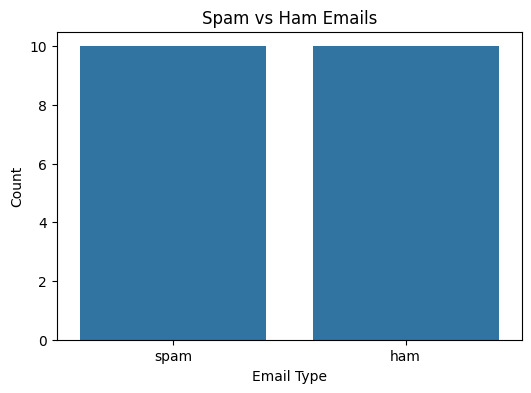

Training Data Shape: (15, 59)
Testing Data Shape: (5, 59)
Model training completed!
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         3
        spam       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



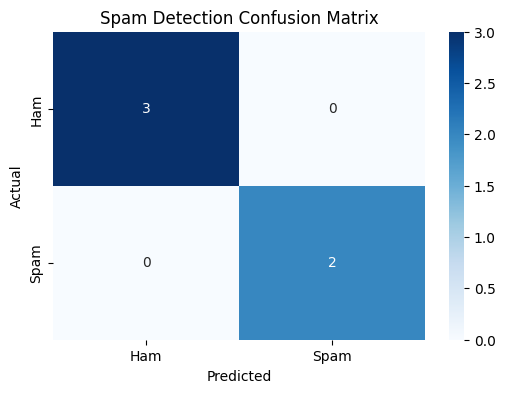

Enter an email/message: jhbfdugiewu
🚨 SPAM EMAIL


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")
data = {
    "message": [
        "Congratulations! You won a free lottery ticket",
        "Win a brand new iPhone now",
        "You have won $100000, claim your prize",
        "Click this link to get your free gift",
        "Congratulations you are selected for a cash prize",
        "Free entry in a weekly competition",
        "Claim your reward now",
        "You have been selected as a lucky winner",
        "Get free money by clicking this link",
        "Urgent! You won a special prize",

        "Hey, are we meeting tomorrow?",
        "Please send me the project report",
        "Can you call me when you are free?",
        "Your appointment is scheduled for tomorrow",
        "Let's meet for lunch today",
        "Please submit your assignment",
        "The meeting starts at 10 AM",
        "Can you send me the notes?",
        "I will reach home by 7 PM",
        "Thank you for your help"
    ],
    "label": [
        "spam","spam","spam","spam","spam",
        "spam","spam","spam","spam","spam",
        "ham","ham","ham","ham","ham",
        "ham","ham","ham","ham","ham"
    ]
}

df = pd.DataFrame(data)

df.head()
print("Dataset Shape:", df.shape)

print("\nClass Distribution:")
print(df["label"].value_counts())

df.info()
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Spam vs Ham Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")

plt.show()
X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training Data Shape:", X_train_tfidf.shape)
print("Testing Data Shape:", X_test_tfidf.shape)
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model training completed!")
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam Detection Confusion Matrix")

plt.show()
def predict_email(message):

    message_tfidf = vectorizer.transform([message])

    prediction = model.predict(message_tfidf)[0]

    if prediction == "spam":
        return "🚨 SPAM EMAIL"
    else:
        return "✅ NORMAL EMAIL"


message = input("Enter an email/message: ")

print(predict_email(message))
